# Healthcare 🩺⚕️💪🫀👩🏻‍⚕️

## 1️⃣ Required Libraries

In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

## 2️⃣ Read the Dataset

In [2]:
path = '/kaggle/input/healthcare-dataset/healthcare_dataset.csv'
df = pd.read_csv(path)

In [3]:
df.shape

(55500, 15)

In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 3️⃣ Exploratory Data Analysis (EDA)

### Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

### Description

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,55500.0,51.539459,19.602454,13.00000,35.000000,52.000000,68.000000,89.000000
Billing Amount,55500.0,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736
Room Number,55500.0,301.134829,115.243069,101.00000,202.000000,302.000000,401.000000,500.000000


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,49992,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.0,NaN,NaN,NaN,51.539459,19.602454,13.0,35.0,52.0,68.0,89.0
Gender,55500,2,Male,27774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,A-,6969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,6,Arthritis,9308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,39876,LLC Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.0,NaN,NaN,NaN,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736


### Check Columns 

In [8]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

#### Remove unnecessary columns

In [9]:
col_drop = ['Name', 'Doctor', 'Room Number', 'Hospital']
df.drop(columns=col_drop, inplace=True)

In [10]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results
0,30,Male,B-,Cancer,2024-01-31,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal
1,62,Male,A+,Obesity,2019-08-20,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,2022-09-22,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal
3,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal


#### Fix Date Columns

In [11]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], format='%Y-%m-%d')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], format='%Y-%m-%d')

### Check Missing Values

In [12]:
df.isna().sum()

Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Insurance Provider    0
Billing Amount        0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### Check Duplications

In [13]:
df.duplicated().sum()

np.int64(534)

### Univariate Analysis

#### Check Numeric Columns 

In [14]:
num_cols =df.select_dtypes(['int64', 'float64']).columns
num_cols

Index(['Age', 'Billing Amount'], dtype='object')

##### Hist + KDE

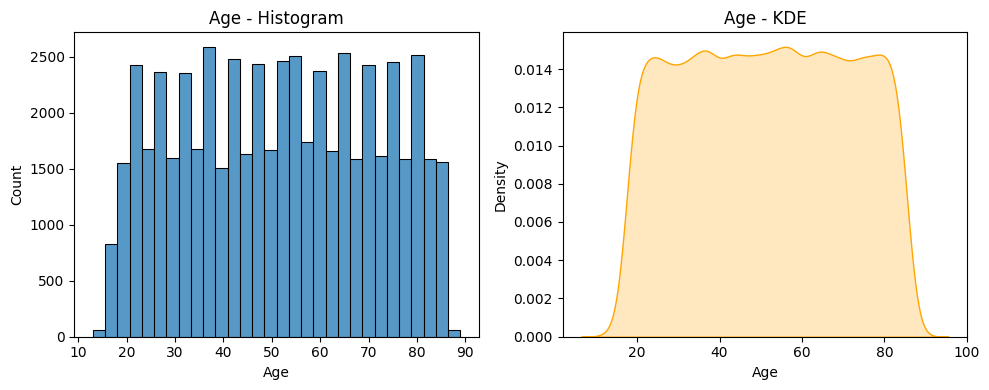

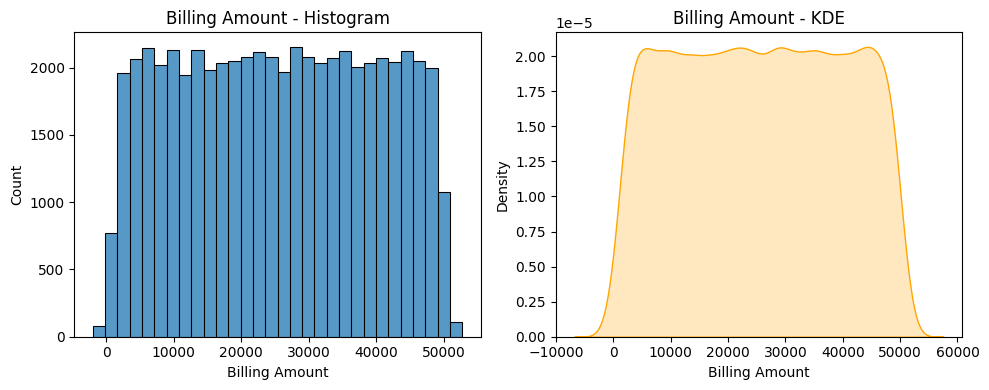

In [15]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram
    sns.histplot(df[col], bins=30, ax=axes[0])
    axes[0].set_title(f'{col} - Histogram')

    # KDE
    sns.kdeplot(df[col], fill=True, ax=axes[1], color='orange')
    axes[1].set_title(f'{col} - KDE')

    plt.tight_layout()
    plt.show()


##### Boxplot + Violinplot

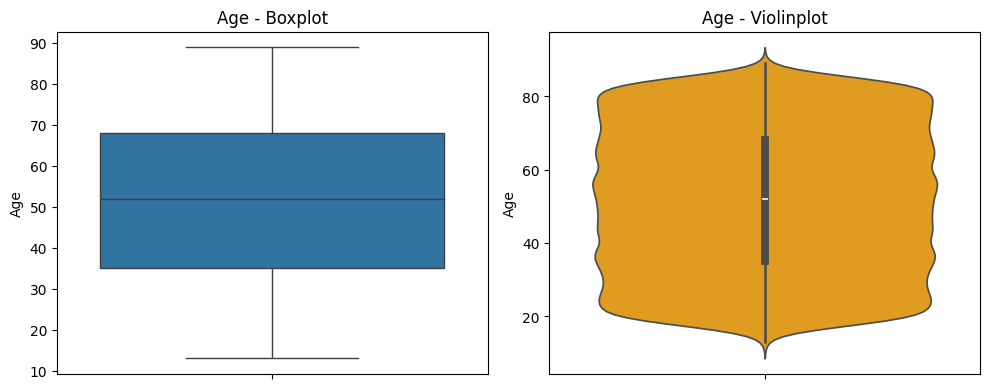

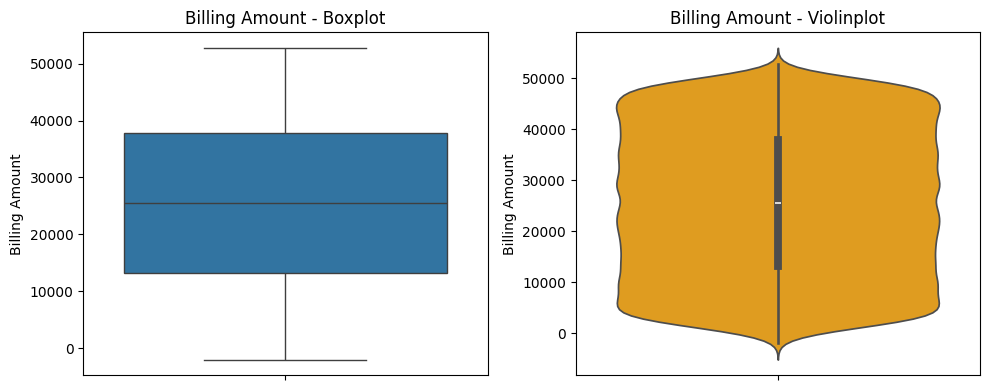

In [16]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Boxplot
    sns.boxplot(df[col], ax=axes[0])
    axes[0].set_title(f'{col} - Boxplot')

    # Violinplot
    sns.violinplot(df[col], fill=True, ax=axes[1], color='orange')
    axes[1].set_title(f'{col} - Violinplot')

    plt.tight_layout()
    plt.show()


#### Check Categorical Columns

In [17]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider',
       'Admission Type', 'Medication', 'Test Results'],
      dtype='object')

In [18]:
for col in cat_cols:
    print(df[col].value_counts())
    print('\n')

Gender
Male      27774
Female    27726
Name: count, dtype: int64


Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64


Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64


Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64


Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64


Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64




/tmp/ipykernel_17/3398846481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set1')


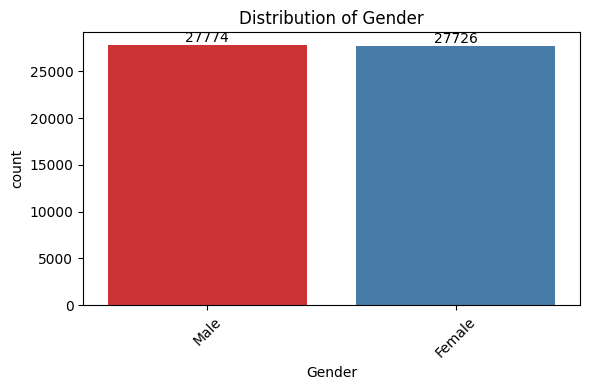

/tmp/ipykernel_17/3398846481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set1')


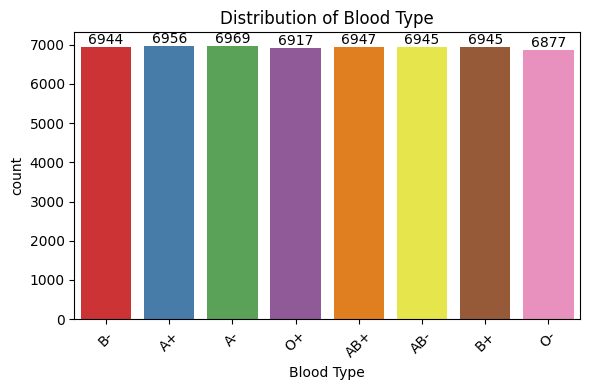

/tmp/ipykernel_17/3398846481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set1')


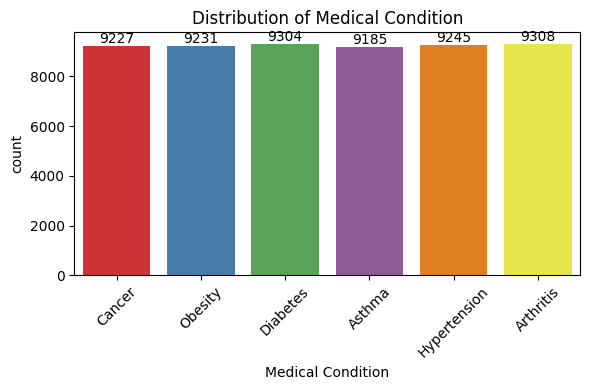

/tmp/ipykernel_17/3398846481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set1')


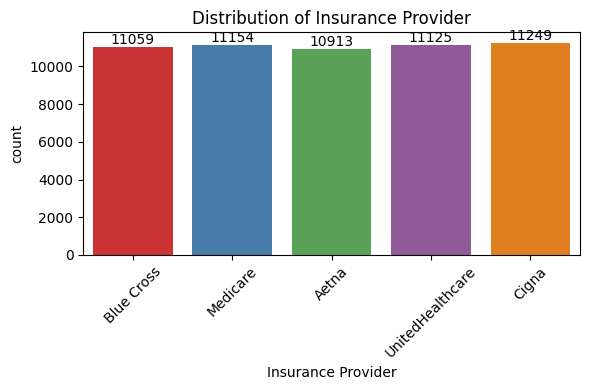

/tmp/ipykernel_17/3398846481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set1')


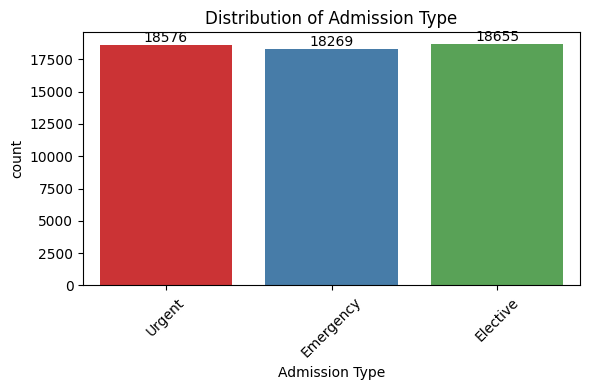

/tmp/ipykernel_17/3398846481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette='Set1')


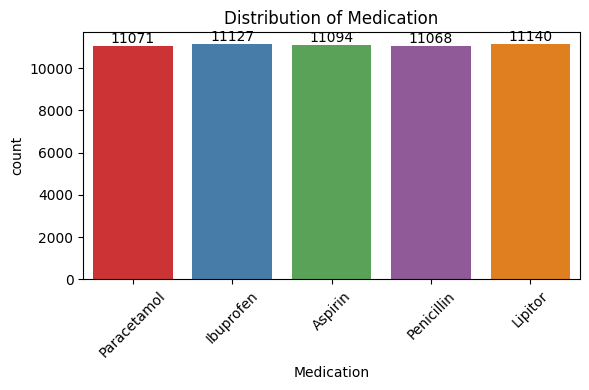

In [19]:
for col in cat_cols[:-1]:
    plt.figure(figsize=(6,4))

    ax = sns.countplot(data=df, x=col, palette='Set1')
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
            (p.get_x() + p.get_width()/2, height),ha='center', va='bottom')

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Check Target Column

In [20]:
df['Test Results']

0              Normal
1        Inconclusive
2              Normal
3            Abnormal
4            Abnormal
             ...     
55495        Abnormal
55496          Normal
55497        Abnormal
55498        Abnormal
55499        Abnormal
Name: Test Results, Length: 55500, dtype: object

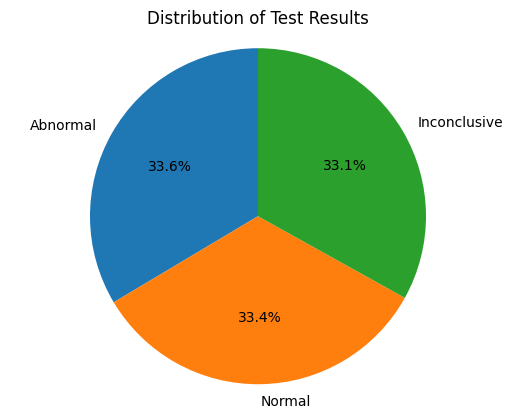

In [21]:
plt.pie(
    df['Test Results'].value_counts().values,
    labels=df['Test Results'].value_counts().index,
    autopct='%1.1f%%',     
    startangle=90,)
plt.title('Distribution of Test Results')
plt.axis('equal')  
plt.show()

### Bivariate Analysis

#### Age with Test Results

In [22]:
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20-30', '30-40', '40-50', '50-60', '60+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=False
)

In [23]:
data = (
    df.groupby(['Age Group', 'Test Results'])
      .size()
      .reset_index(name='count')
)

pivot = data.pivot(
    index='Age Group',
    columns='Test Results',
    values='count'
)

/tmp/ipykernel_17/3885110494.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age Group', 'Test Results'])


<Figure size 1200x600 with 0 Axes>

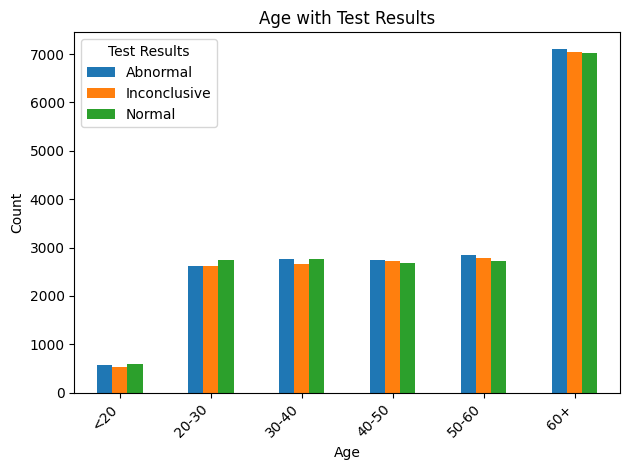

In [24]:
plt.figure(figsize=(12,6))
pivot.plot(kind='bar')
plt.title('Age with Test Results')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Test Results')
plt.tight_layout()
plt.show()

In [25]:
df.drop('Age Group', axis=1, inplace=True)

#### Gender with Test Results

In [26]:
data = (
    df.groupby(['Gender', 'Test Results'])
      .size()
      .reset_index(name='count')
)

pivot = data.pivot(
    index='Gender',
    columns='Test Results',
    values='count'
)

In [27]:
pivot

Test Results,Abnormal,Inconclusive,Normal
Gender,,,
Female,9338,9216,9172
Male,9289,9140,9345


<Figure size 1200x600 with 0 Axes>

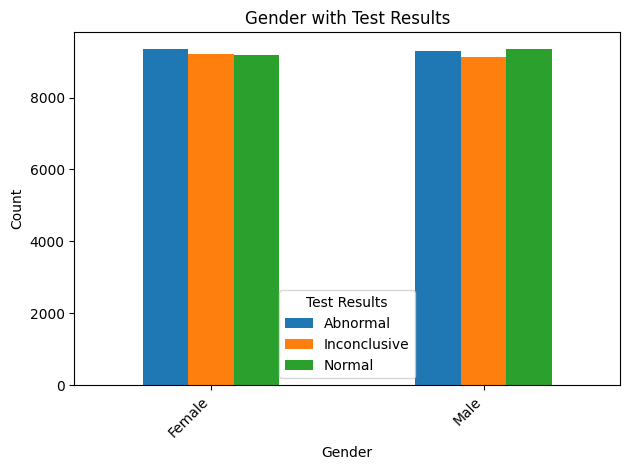

In [28]:
plt.figure(figsize=(12,6))
pivot.plot(kind='bar')
plt.title('Gender with Test Results')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Test Results')
plt.tight_layout()
plt.show()

#### Medication with Test Results

In [29]:
df['Medication'].value_counts()

Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

In [30]:
data = (
    df.groupby(['Medication', 'Test Results'])
      .size()
      .reset_index(name='count')
)

pivot = data.pivot(
    index='Medication',
    columns='Test Results',
    values='count'
)

In [31]:
pivot

Test Results,Abnormal,Inconclusive,Normal
Medication,,,
Aspirin,3732,3624,3738
Ibuprofen,3747,3645,3735
Lipitor,3707,3746,3687
Paracetamol,3737,3681,3653
Penicillin,3704,3660,3704


<Figure size 1200x600 with 0 Axes>

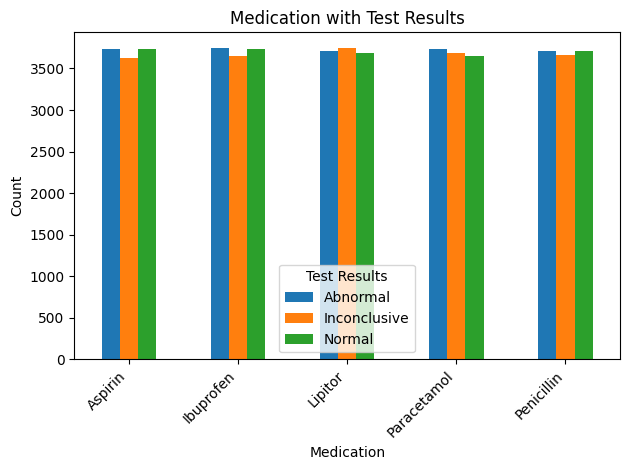

In [32]:
plt.figure(figsize=(12,6))
pivot.plot(kind='bar')
plt.title('Medication with Test Results')
plt.xlabel('Medication')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Test Results')
plt.tight_layout()
plt.show()

### Realations

In [33]:
insurance_costs = np.round(df.groupby('Insurance Provider')['Billing Amount'].sum(),2).reset_index()
insurance_costs['%Insurance Costs'] = np.round((insurance_costs['Billing Amount'] / df['Billing Amount'].sum() * 100),2)
display(insurance_costs)

,Insurance Provider,Billing Amount,%Insurance Costs
0,Aetna,2.788631e+08,19.67
1,Blue Cross,2.832543e+08,19.98
2,Cigna,2.871393e+08,20.26
3,Medicare,2.857208e+08,20.16
4,UnitedHealthcare,2.824545e+08,19.93


/tmp/ipykernel_17/503119552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Medical Condition', y='Billing Amount', estimator='mean', palette='viridis')


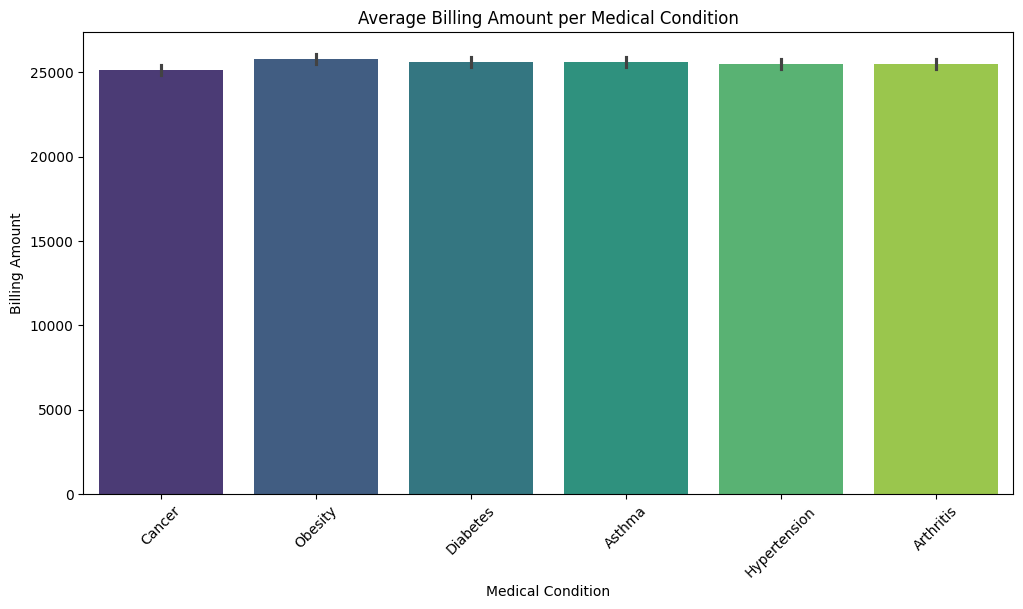

In [34]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Medical Condition', y='Billing Amount', estimator='mean', palette='viridis')
plt.title('Average Billing Amount per Medical Condition')
plt.xticks(rotation=45)
plt.show()

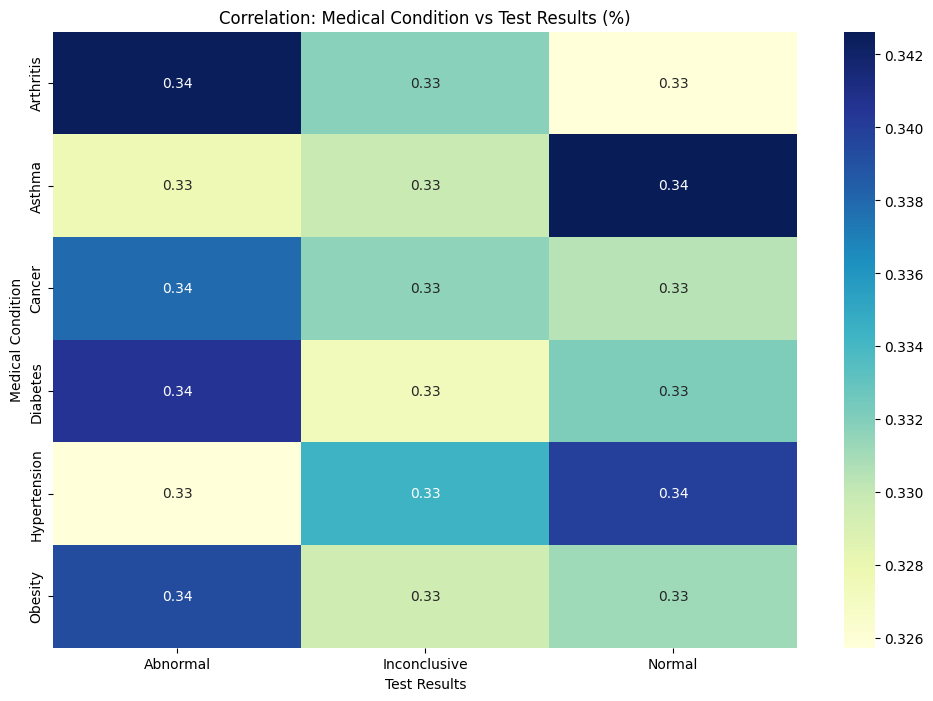

In [35]:
ct = pd.crosstab(df['Medical Condition'], df['Test Results'], normalize='index')
plt.figure(figsize=(12,8))
sns.heatmap(ct, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation: Medical Condition vs Test Results (%)')
plt.show()

## 4️⃣ Feature Engineering

In [36]:
df['Stay Duration'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

In [37]:
df['Stay Duration']

0         2
1         6
2        15
3        30
4        20
         ..
55495    30
55496     9
55497    28
55498     6
55499    27
Name: Stay Duration, Length: 55500, dtype: int64

### Average Hospital Stay Duration per Month

In [38]:
df['Month'] = df['Date of Admission'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
monthly_sum = df.groupby('Month')['Stay Duration'].sum().reset_index()

/tmp/ipykernel_17/3850260810.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sum = df.groupby('Month')['Stay Duration'].sum().reset_index()


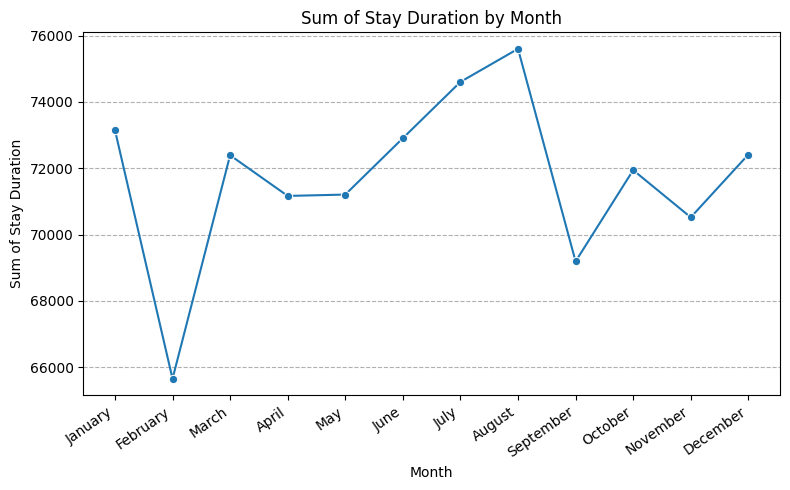

In [39]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=monthly_sum, x='Month', y='Stay Duration', marker='o')
plt.title('Sum of Stay Duration by Month')
plt.xlabel('Month')
plt.ylabel('Sum of Stay Duration')
plt.xticks(rotation=35, ha='right', color='black')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [40]:
df.drop(['Date of Admission', 'Discharge Date', 'Month'], axis=1, inplace=True)

## 5️⃣ Data Transformation

In [41]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Stay Duration
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,2
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,15
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,20


In [42]:
cols =  ['Blood Type', 'Medical Condition', 'Admission Type', 'Insurance Provider', 
         'Medication', 'Test Results', 'Gender']

le = LabelEncoder()
for col in cols :
    df[col] = le.fit_transform(df[col])

In [43]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Stay Duration
0,30,1,5,2,1,18856.281306,2,3,2,2
1,62,1,0,5,3,33643.327287,1,1,1,6
2,76,0,1,5,0,27955.096079,1,0,2,15
3,28,0,6,3,3,37909.782410,0,1,0,30
4,43,0,2,2,0,14238.317814,2,4,0,20


## 6️⃣ Split Data into Features and Target 

In [44]:
X = df.drop(columns=['Test Results'])
y = df['Test Results']

## 7️⃣ Split Data into Train and Test Sets 

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
X_train.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Stay Duration
45174,22,0,6,0,0,42298.681572,0,1,21
10214,22,1,5,3,1,2437.435883,1,3,22
43199,81,0,0,0,4,5600.450992,1,3,21
31626,80,0,4,1,1,39533.300775,0,3,13
9273,26,0,2,5,4,37691.176763,0,1,27


In [47]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [48]:
X_train

array([[-1.50874356e+00, -1.00202909e+00,  1.09693660e+00, ...,
        -1.21554984e+00, -7.07266069e-01,  6.31129198e-01],
       [-1.50874356e+00,  9.97975023e-01,  6.59647169e-01, ...,
         5.36211331e-03,  7.07138645e-01,  7.46507882e-01],
       [ 1.50032606e+00, -1.00202909e+00, -1.52679999e+00, ...,
         5.36211331e-03,  7.07138645e-01,  6.31129198e-01],
       ...,
       [-1.40674120e+00, -1.00202909e+00,  6.59647169e-01, ...,
         5.36211331e-03, -6.37119241e-05,  2.84993146e-01],
       [ 1.24532016e+00,  9.97975023e-01, -1.52679999e+00, ...,
         5.36211331e-03, -1.41446843e+00, -1.09955106e+00],
       [-9.47730577e-01, -1.00202909e+00,  2.22357737e-01, ...,
         1.22627407e+00, -6.37119241e-05,  9.77265250e-01]])

## 8️⃣ Modeling

### Logistic regression

In [49]:
log_model = LogisticRegression(
    max_iter=1000,          
    class_weight='balanced',  
    solver='lbfgs',
    random_state=42
)
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [50]:
print("\n--- Logistic Regerssion Results ---")

y_pred = log_model.predict(X_test)
print("Performance:\n", classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


--- Logistic Regerssion Results ---
Performance:
               precision    recall  f1-score   support

           0       0.33      0.18      0.23      3754
           1       0.33      0.42      0.37      3617
           2       0.34      0.41      0.37      3729

    accuracy                           0.33     11100
   macro avg       0.33      0.33      0.32     11100
weighted avg       0.33      0.33      0.32     11100

Accuracy: 0.33288288288288287


### Random Forest 

In [51]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [52]:
print("\n--- Random Forest Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


--- Random Forest Results ---
Accuracy: 0.4376576576576577

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.45      0.44      3754
           1       0.43      0.42      0.43      3617
           2       0.45      0.44      0.44      3729

    accuracy                           0.44     11100
   macro avg       0.44      0.44      0.44     11100
weighted avg       0.44      0.44      0.44     11100



### SVM

In [53]:
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

In [54]:
print("\n--- SVM (SVC) Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


--- SVM (SVC) Results ---
Accuracy: 0.3411711711711712

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.37      0.36      3754
           1       0.33      0.33      0.33      3617
           2       0.35      0.33      0.34      3729

    accuracy                           0.34     11100
   macro avg       0.34      0.34      0.34     11100
weighted avg       0.34      0.34      0.34     11100



### 📌 Final Notes on the Dataset and Model Performance

It is important to highlight that this dataset is **synthetic**, meaning it was artificially generated and does not represent real patient data.  
The dataset was created for **educational and experimental purposes**, allowing users to practice data analysis and machine learning techniques without privacy or ethical concerns.

Due to the synthetic nature of the data:
- Feature–target relationships are not necessarily strong or realistic
- A significant amount of **noise** is intentionally present
- Class overlap makes the prediction task more challenging

As a result, achieving an **accuracy of around 30%** is both reasonable and expected.  
Attempting to significantly push the accuracy beyond this point may lead to **overfitting** rather than genuine model improvement.

Therefore, the primary objective of this project is not maximizing accuracy,  
but rather **understanding the data, experimenting with different models, and correctly interpreting the results**,  
which aligns with the intended purpose of using synthetic datasets.


## Thank You 🎀🫶🏻💌